# **DUSt3R :3D Reconstruction From 2D Images :**

In [ ]:
# uv pip install torch==2.7.0+cu118 torchvision==0.22.0+cu118 --index-url https://download.pytorch.org/whl/cu118

3D Reconstruction/
│
├── data/
│   └── input/
│       └── video.mp4
│
├── results/
│   └── dust3r/
│       │
│       ├── exp_01_baseline/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   ├── confidence.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_02_oneref/
│       │   ├── dataset/
│       │   │   ├── frames/
│       │   │   └── dataset_info.json
│       │   │
│       │   ├── results/
│       │   │   ├── point_cloud.ply
│       │   │   └── metadata.json
│       │   │
│       │   └── logs/
│       │
│       ├── exp_03_more_frames/
│       │   ├── dataset/
│       │   ├── results/
│       │   └── logs/
│       │
│       └── ...
│
├── src/
│   └── dust3r/
│       ├── frame_extractor.py
│       ├── reconstruction.py
│       ├── visualization.py
│       └── pipeline.py
│
└── notebook/
    └── dust3r/
        ├── 01_data_processing.ipynb
        ├── 02_two_image_test.ipynb
        ├── 03_global_alignment.ipynb
        └── 04_experiments.ipynb

## **Dust3R dataset Preprocessing :**

In [13]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent))

In [14]:
Path.cwd()

WindowsPath('d:/3D Reconstruction - 2/notebook')

In [15]:
from src.dust3r.data_preprocessing import extract_uniform_frames

In [16]:
Path.cwd().parent

WindowsPath('d:/3D Reconstruction - 2')

In [17]:

PROJECT_ROOT = Path.cwd().parent

video_path = PROJECT_ROOT / "video"/ "video.mp4"

video_path

WindowsPath('d:/3D Reconstruction - 2/video/video.mp4')

In [18]:


output_dir = (
        PROJECT_ROOT
        /"src"
        / "results"
        / "dust3r"
        / "exp_01_baseline"
        / "dataset"
        / "frames"
    )

extract_uniform_frames(
        video_path=video_path,
        output_dir=output_dir,
        num_frames=20,
    )

Video: d:\3D Reconstruction - 2\video\video.mp4
Original frames: 397
Original FPS: 30.00
Selected frames: 20
Saved to: d:\3D Reconstruction - 2\src\results\dust3r\exp_01_baseline\dataset\frames
Metadata: d:\3D Reconstruction - 2\src\results\dust3r\exp_01_baseline\dataset\dataset_info.json


In [19]:

frames=sorted(output_dir.glob("*.jpg"))

print(f'Number of Frames : {len(frames)}')

for frame in frames:
    print(frame.name)

Number of Frames : 20
frame_0000.jpg
frame_0001.jpg
frame_0002.jpg
frame_0003.jpg
frame_0004.jpg
frame_0005.jpg
frame_0006.jpg
frame_0007.jpg
frame_0008.jpg
frame_0009.jpg
frame_0010.jpg
frame_0011.jpg
frame_0012.jpg
frame_0013.jpg
frame_0014.jpg
frame_0015.jpg
frame_0016.jpg
frame_0017.jpg
frame_0018.jpg
frame_0019.jpg


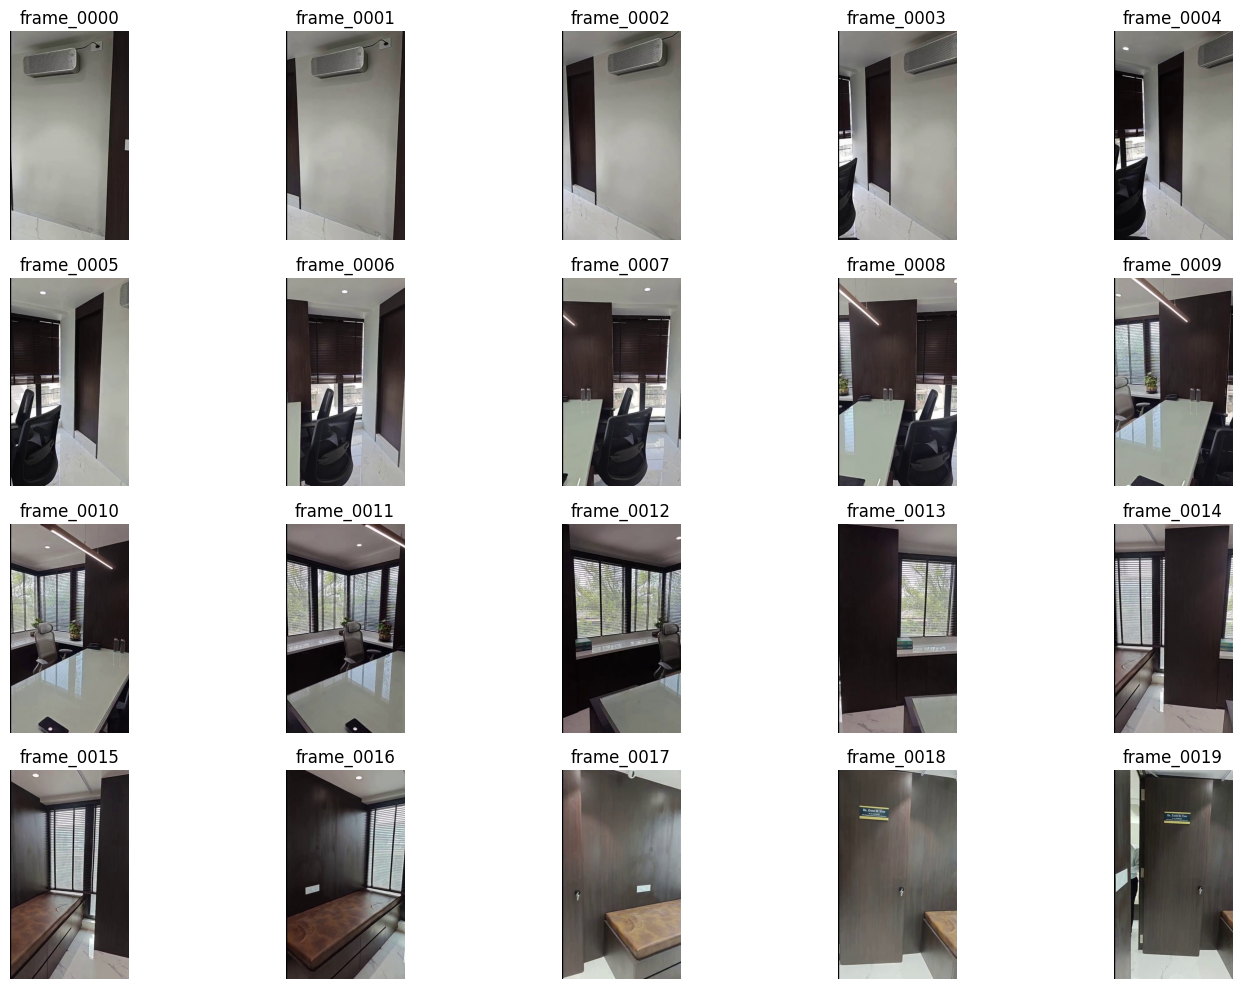

In [20]:
import matplotlib.pyplot as plt
from PIL import Image


fig,axes=plt.subplots(4,5,figsize=(15,10))

for ax ,frame_path in zip(axes.flat,frames):
    image=Image.open(frame_path)

    ax.imshow(image)
    ax.set_title(frame_path.stem)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
from PIL import Image

for frame_path in frames[:3]:
    image = Image.open(frame_path)

    print(
        frame_path.name,
        "size =", image.size,
        "mode =", image.mode
    )

frame_0000.jpg size = (408, 720) mode = RGB
frame_0001.jpg size = (408, 720) mode = RGB
frame_0002.jpg size = (408, 720) mode = RGB


## **Working with Dust3R Model :**

In [22]:
# !git clone --recursive https://github.com/naver/dust3r

In [23]:
# # * downloading the Model :

from src.dust3r.model_manager import get_checkpoint

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "dust3r"
    / "checkpoints"
)

CHECKPOINT_DIR


WindowsPath('d:/3D Reconstruction - 2/dust3r/checkpoints')

In [24]:
checkpoint_path = get_checkpoint(
    model_name="512_dpt",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)


Destination: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth

██████████████████████████████ 100.00% | 2179.2/2179.2 MB | 1.82 MB/s | ETA: 0ss0ss

Download completed.
Checkpoint: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth
d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pth


In [26]:
checkpoint_path = get_checkpoint(
    model_name="512_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)


Destination: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth

██████████████████████████████ 100.00% | 2031.0/2031.0 MB | 1.21 MB/s | ETA: 0ss0sss

Download completed.
Checkpoint: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth
d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_512_linear.pth


In [27]:
checkpoint_path = get_checkpoint(
    model_name="224_linear",
    checkpoint_dir=CHECKPOINT_DIR,
)

print(checkpoint_path)


Destination: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth

██████████████████████████████ 100.00% | 2031.0/2031.0 MB | 1.51 MB/s | ETA: 0ss0sss

Download completed.
Checkpoint: d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth
d:\3D Reconstruction - 2\dust3r\checkpoints\DUSt3R_ViTLarge_BaseDecoder_224_linear.pth
